# Model 1 — Logistic Regression
**Student:** IT25101431 — Nasik.F.M  
**Dataset:** Online Shoppers Purchasing Intention  
**Task:** Binary classification — predict `Revenue` (purchase = 1, no purchase = 0)

## 1. Import libraries

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)

RANDOM_STATE = 42
BASE = ".." if os.path.exists("../data/raw/online_shoppers_intention.csv") else "."
DATA_PATH = f"{BASE}/data/raw/online_shoppers_intention.csv"
FIG_DIR = f"{BASE}/results/model_visualizations"
OUT_DIR = f"{BASE}/results/outputs"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

## 2. Load the dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


Revenue
False    10422
True      1908
Name: count, dtype: int64
Revenue
False    0.845
True     0.155
Name: proportion, dtype: float64


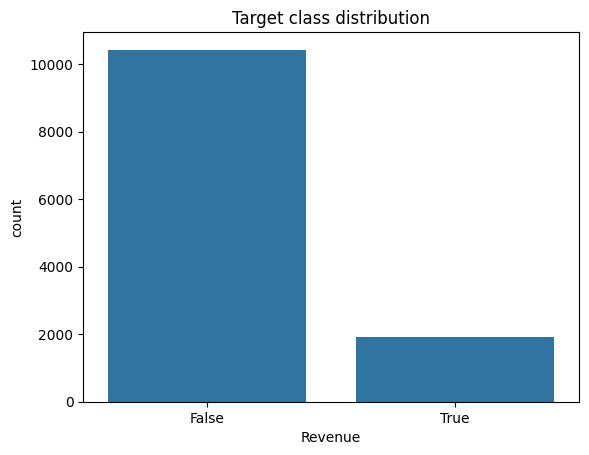

In [3]:
print(df["Revenue"].value_counts())
print(df["Revenue"].value_counts(normalize=True).round(3))
sns.countplot(x="Revenue", data=df)
plt.title("Target class distribution")
plt.savefig(f"{FIG_DIR}/lr_01_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

The target is imbalanced (~85% no purchase / ~15% purchase), so accuracy alone is misleading. We focus on **ROC-AUC, F1 and Recall** for the purchase class and use `class_weight='balanced'`.

## 3. Prepare features and target

In [4]:
df["Weekend"] = df["Weekend"].astype(int)
y = df["Revenue"].astype(int)
X = df.drop(columns=["Revenue"])

categorical_cols = ["Month", "VisitorType", "OperatingSystems", "Browser", "Region", "TrafficType"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Weekend']
Categorical: ['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']


## 4. Train / test split (stratified 80 / 20)
We split **before** any scaling or encoding is fitted, to avoid data leakage.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape)

(9864, 17) (2466, 17)


## 5. Preprocessing pipeline
- Numeric: **StandardScaler** (Logistic Regression is sensitive to feature scale).
- Categorical: **One-Hot Encoding** (`handle_unknown='ignore'` for unseen categories in test data).

In [6]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

## 6. Baseline model (default Logistic Regression)

In [7]:
baseline = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])
baseline.fit(X_train, y_train)
yb = baseline.predict(X_test)
print("Baseline accuracy:", round(accuracy_score(y_test, yb), 4))
print("Baseline recall  :", round(recall_score(y_test, yb), 4))
print("Baseline F1      :", round(f1_score(y_test, yb), 4))

Baseline accuracy: 0.8808
Baseline recall  : 0.3586
Baseline F1      : 0.4824


High accuracy but low recall — the model misses many buyers because of class imbalance.

## 7. Hyperparameter tuning with GridSearchCV (5-fold stratified CV, scoring = F1)
- `C`: inverse regularization strength (smaller = stronger regularization)
- `l1_ratio`: 0 = L2 (Ridge) penalty, 1 = L1 (Lasso) penalty
- `class_weight`: `balanced` gives more weight to the minority (purchase) class

In [8]:
pipe = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE)),
])
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0.0, 1.0],
    "model__class_weight": [None, "balanced"],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV F1 :", round(grid.best_score_, 4))
best_model = grid.best_estimator_

Best params: {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__l1_ratio': 1.0}
Best CV F1 : 0.654


In [9]:
cv_auc = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="roc_auc")
print("CV ROC-AUC: %.4f ± %.4f" % (cv_auc.mean(), cv_auc.std()))

CV ROC-AUC: 0.9084 ± 0.0047


## 8. Evaluate on the test set

In [10]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
}
print(pd.Series(results).drop("Model").astype(float).round(4))
print()
print(classification_report(y_test, y_pred, target_names=["No purchase", "Purchase"]))

Accuracy     0.8719
Precision    0.5673
Recall       0.7277
F1           0.6376
ROC_AUC      0.8965
dtype: float64

              precision    recall  f1-score   support

 No purchase       0.95      0.90      0.92      2084
    Purchase       0.57      0.73      0.64       382

    accuracy                           0.87      2466
   macro avg       0.76      0.81      0.78      2466
weighted avg       0.89      0.87      0.88      2466



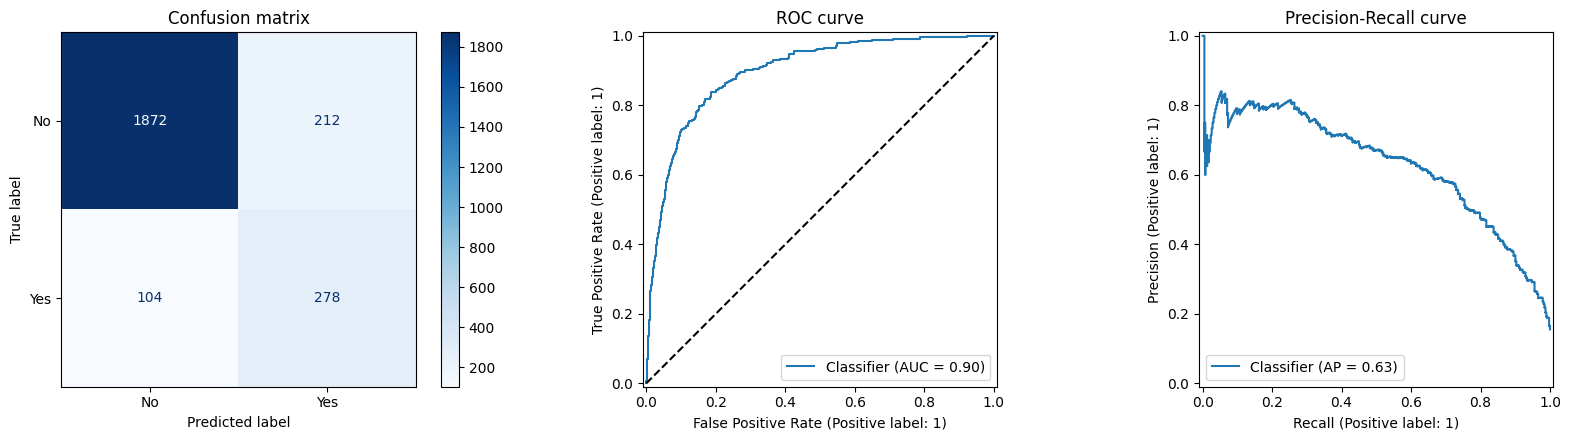

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No", "Yes"], cmap="Blues", ax=ax[0])
ax[0].set_title("Confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[1])
ax[1].plot([0, 1], [0, 1], "k--")
ax[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax[2])
ax[2].set_title("Precision-Recall curve")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/lr_02_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Feature importance (model coefficients)
Positive coefficient → increases purchase probability; negative → decreases it.

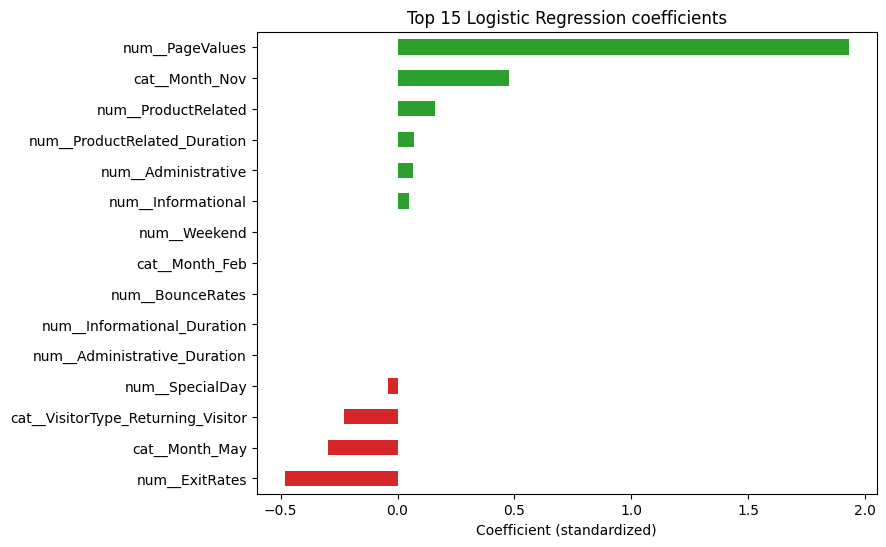

num__PageValues                       1.930
num__ExitRates                       -0.482
cat__Month_Nov                        0.478
cat__Month_May                       -0.300
cat__VisitorType_Returning_Visitor   -0.230
num__ProductRelated                   0.161
num__ProductRelated_Duration          0.071
num__Administrative                   0.068
num__Informational                    0.050
num__SpecialDay                      -0.040
num__Weekend                          0.003
num__BounceRates                      0.000
num__Administrative_Duration          0.000
num__Informational_Duration           0.000
cat__Month_Feb                        0.000
dtype: float64

In [12]:
feat_names = best_model.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(best_model.named_steps["model"].coef_[0], index=feat_names)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15)
plt.figure(figsize=(8, 6))
top.sort_values().plot.barh(color=["tab:red" if v < 0 else "tab:green" for v in top.sort_values()])
plt.title("Top 15 Logistic Regression coefficients")
plt.xlabel("Coefficient (standardized)")
plt.savefig(f"{FIG_DIR}/lr_03_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()
top.round(3)

## 10. Decision threshold analysis
The default threshold is 0.5. We check how precision / recall / F1 change with the threshold (chosen on training CV data would be stricter; shown here for analysis).

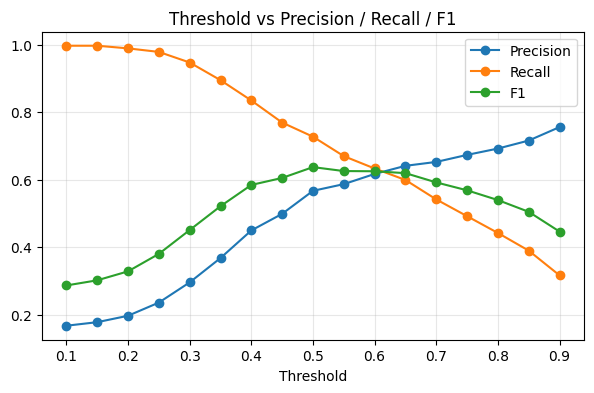

,Threshold,Precision,Recall,F1
0,0.10,0.168,0.997,0.287
1,0.15,0.178,0.997,0.302
2,0.20,0.197,0.990,0.329
3,0.25,0.236,0.979,0.380
4,0.30,0.296,0.948,0.451
5,0.35,0.368,0.895,0.522
6,0.40,0.450,0.835,0.585
7,0.45,0.499,0.770,0.606
8,0.50,0.567,0.728,0.638
9,0.55,0.587,0.670,0.626


In [13]:
th = np.arange(0.1, 0.91, 0.05)
rows = [(t, precision_score(y_test, (y_prob >= t).astype(int), zero_division=0),
         recall_score(y_test, (y_prob >= t).astype(int)),
         f1_score(y_test, (y_prob >= t).astype(int))) for t in th]
thr = pd.DataFrame(rows, columns=["Threshold", "Precision", "Recall", "F1"])
thr.plot(x="Threshold", figsize=(7, 4), marker="o")
plt.title("Threshold vs Precision / Recall / F1")
plt.grid(alpha=0.3)
plt.savefig(f"{FIG_DIR}/lr_04_threshold.png", dpi=150, bbox_inches="tight")
plt.show()
thr.round(3)

## 11. Save the model and results

In [14]:
joblib.dump(best_model, f"{OUT_DIR}/logistic_regression_model.pkl")
pd.DataFrame([results]).to_csv(f"{OUT_DIR}/model_results_logistic_regression.csv", index=False)
print("Saved model and results.")

Saved model and results.


## 12. Conclusion
- Logistic Regression with scaling + one-hot encoding and `class_weight='balanced'` gives a strong, interpretable baseline.
- `PageValues` is by far the strongest positive predictor; high `ExitRates` reduce purchase likelihood; November and returning/new visitor type also matter.
- Balancing trades some accuracy for much higher recall on buyers — more useful for the business goal.
- This result is the baseline for comparing the other 5 models.